# Tutorial: Greedy Best-First Search e A* Search

Este tutorial foi montado **a partir do notebook `Laboratorio_-_Metodos_de_Busca_I`**.

A ideia é aproveitar a mesma modelagem já usada no laboratório:

- as classes `Problem`, `GraphProblem`, `SimpleGraph` e `Node`;
- as funções auxiliares `state_path`, `verbose` e `agent_simulation`;
- o mesmo grafo de cidades do exemplo `Natal -> Pipa`.

A partir dessa base, vamos acrescentar dois algoritmos de busca informada:

- **Greedy Best-First Search**
- **A* Search**


## Objetivos de Aprendizagem

- Entender a diferença entre Greedy Best-First Search e A* Search.
- Interpretar o papel de `g(n)`, `h(n)` e `f(n)` na escolha dos nós.
- Observar como a heurística influencia a ordem de expansão e o caminho encontrado.
- Implementar e adaptar versões didáticas de algoritmos de busca informada.
- Comparar diferentes heurísticas no mesmo problema de busca.

**Key takeaways**

Greedy Best-First Search decide com base apenas na heurística, enquanto o A* combina custo acumulado e estimativa restante. A qualidade da heurística afeta diretamente a eficiência da busca: uma heurística mais informativa tende a reduzir expansões desnecessárias e a direcionar melhor o algoritmo até o objetivo.


## Ajustando ambiente


In [24]:
import matplotlib.pyplot as plt
import networkx as nx


## Reaproveitando as classes do laboratório

Abaixo estão as mesmas estruturas usadas no laboratório anterior.


In [25]:
class Problem:
    def __init__(self, initial, goal=None):
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        raise NotImplementedError

    def result(self, state, action):
        raise NotImplementedError

    def goal_test(self, state):
        return state == self.goal

    def path_cost(self, c, state1, action, state2):
        return c + 1


class GraphProblem(Problem):
    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return list(self.graph.get(state).keys())

    def result(self, state, action):
        return action

    def path_cost(self, cost_so_far, state1, action, state2):
        edge_cost = self.graph.get(state1, state2)
        if edge_cost is None:
            return float('inf')
        return cost_so_far + edge_cost


class SimpleGraph:
    def __init__(self, graph_dict):
        self.graph_dict = graph_dict

    def get(self, a, b=None):
        links = self.graph_dict.setdefault(a, {})
        if b is None:
            return links
        return links.get(b)


class Node:
    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost
        self.depth = 0 if parent is None else parent.depth + 1

    def __repr__(self):
        return '<Node {}>'.format(self.state)

    def __lt__(self, node):
        return self.state < node.state

    def expand(self, problem):
        return [self.child_node(problem, action) for action in problem.actions(self.state)]

    def child_node(self, problem, action):
        next_state = problem.result(self.state, action)
        return Node(
            next_state,
            self,
            action,
            problem.path_cost(self.path_cost, self.state, action, next_state),
        )

    def solution(self):
        return [node.action for node in self.path()[1:]]

    def path(self):
        node = self
        path_back = []
        while node is not None:
            path_back.append(node)
            node = node.parent
        path_back.reverse()
        return path_back

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        return hash(self.state)


## Reaproveitando as funções auxiliares do laboratório


In [26]:
class SimpleProblemSolvingAgentProgram:
    def __init__(self, initial_state=None):
        self.state = initial_state
        self.seq = []

    def __call__(self, percept):
        self.state = self.update_state(self.state, percept)
        if not self.seq:
            goal = self.formulate_goal(self.state)
            problem = self.formulate_problem(self.state, goal)
            self.seq = self.search(problem)
            if not self.seq:
                return None
        return self.seq.pop(0)

    def update_state(self, state, percept):
        raise NotImplementedError

    def formulate_goal(self, state):
        raise NotImplementedError

    def formulate_problem(self, state, goal):
        raise NotImplementedError

    def search(self, problem):
        raise NotImplementedError


class SearchAgent(SimpleProblemSolvingAgentProgram):
    def __init__(self, goal, search_algorithm, graph):
        super().__init__(initial_state=None)
        self.goal = goal
        self.search_algorithm = search_algorithm
        self.graph = graph

    def update_state(self, state, percept):
        return percept

    def formulate_goal(self, state):
        return self.goal

    def formulate_problem(self, state, goal):
        return GraphProblem(state, goal, self.graph)

    def search(self, problem):
        node = self.search_algorithm(problem)
        if node is None:
            return []
        return node.solution()


def state_path(node):
    if node is None:
        return None
    return [step.state for step in node.path()]


def verbose(node):
    if node is None:
        return {
            'encontrou': False,
            'caminho': None,
            'acoes': None,
            'custo': None,
        }
    return {
        'encontrou': True,
        'caminho': state_path(node),
        'acoes': node.solution(),
        'custo': node.path_cost,
    }


def agent_simulation(agent, initial_state, max_step=20):
    state = initial_state
    trajectory = [state]
    actions = []

    for _ in range(max_step):
        action = agent(state)
        if action is None:
            break

        actions.append(action)
        state = action
        trajectory.append(state)

        if state == agent.goal:
            break

    return actions, trajectory


## Reaproveitando o mesmo grafo do laboratório

Vamos usar exatamente o mesmo ambiente do notebook anterior.


In [27]:
environment = {
    'Natal': {'Parnamirim': 1, 'Extremoz': 1, 'São Gonçalo do Amarante': 1, 'Macaíba': 1},
    'Parnamirim': {'Natal': 1, 'São José de Mipibu': 1, 'Macaíba': 1},
    'Extremoz': {'Natal': 1},
    'São Gonçalo do Amarante': {'Natal': 1, 'Macaíba': 1, 'Ceará-Mirim': 1},
    'Macaíba': {'Natal': 1, 'Parnamirim': 1, 'São Gonçalo do Amarante': 1, 'Ielmo Marinho': 1, 'Vera Cruz': 1},
    'Ceará-Mirim': {'São Gonçalo do Amarante': 1},
    'Ielmo Marinho': {'Macaíba': 1},
    'Vera Cruz': {'Macaíba': 1, 'Monte Alegre': 1},
    'Monte Alegre': {'Vera Cruz': 1, 'São José de Mipibu': 1},
    'São José de Mipibu': {'Parnamirim': 1, 'Goianinha': 1, 'Monte Alegre': 1},
    'Goianinha': {'São José de Mipibu': 1, 'Tibau do Sul': 1},
    'Tibau do Sul': {'Goianinha': 1, 'Pipa': 1},
    'Pipa': {'Tibau do Sul': 1}
}

graph = SimpleGraph(environment)
problem = GraphProblem('Natal', 'Pipa', graph)

print('Estado inicial:', problem.initial)
print('Objetivo:', problem.goal)
print('Ações possíveis em Natal:', problem.actions('Natal'))


Estado inicial: Natal
Objetivo: Pipa
Ações possíveis em Natal: ['Parnamirim', 'Extremoz', 'São Gonçalo do Amarante', 'Macaíba']


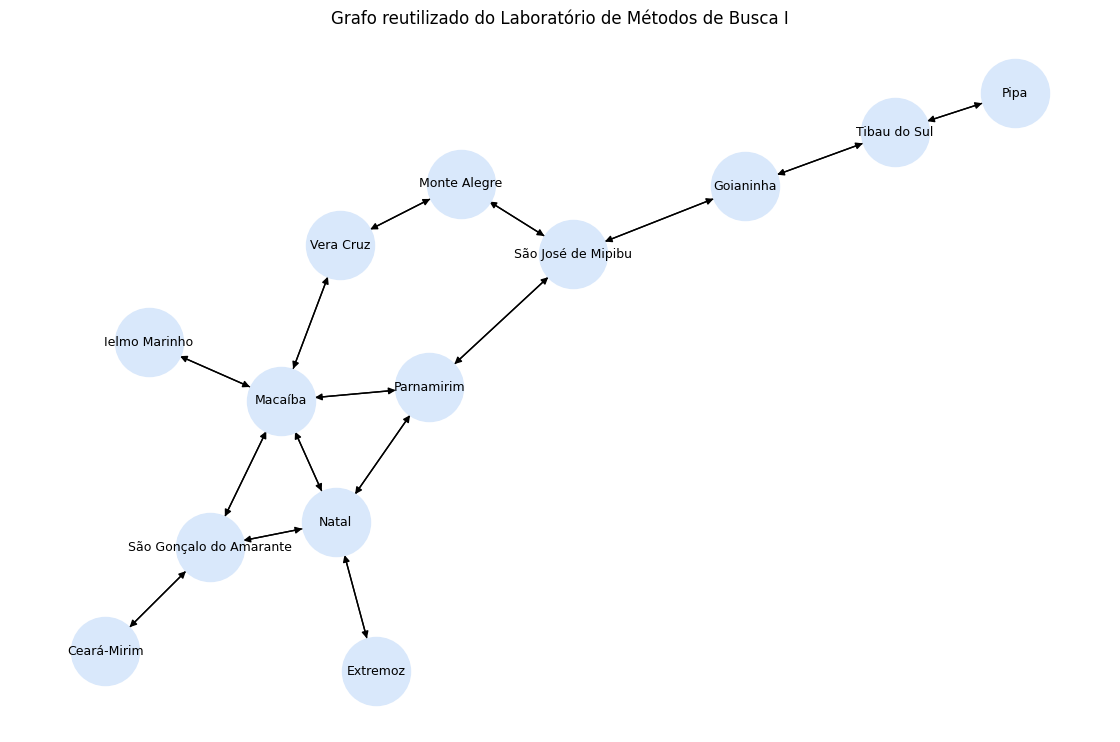

In [28]:
# Visualização do mesmo grafo usado no laboratório
G = nx.DiGraph()
for origem, destinos in environment.items():
    for destino in destinos:
        G.add_edge(origem, destino)

pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(11, 7))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='#d9e8fb',
    node_size=2400,
    font_size=9,
    arrows=True,
)
plt.title('Grafo reutilizado do Laboratório de Métodos de Busca I')
plt.show()


## O que muda agora?

No laboratório anterior, usamos buscas **não informadas** como BFS e DFS.

Agora vamos usar uma **heurística**.

Uma heurística é um valor que tenta responder:

> "Qual estado parece mais promissor para chegar ao objetivo?"

Para simplificar, vamos definir manualmente valores heurísticos para o objetivo `Pipa`.

Esses valores foram escolhidos para fins didáticos, de modo que possamos observar uma diferença clara entre Greedy e A*.


In [29]:
heuristica = {
    'Natal': 45,
    'Parnamirim': 41,
    'Extremoz': 66,
    'São Gonçalo do Amarante': 57,
    'Macaíba': 53,
    'Ceará-Mirim': 78,
    'Ielmo Marinho': 82,
    'Vera Cruz': 48,
    'Monte Alegre': 35,
    'São José de Mipibu': 27,
    'Goianinha': 18,
    'Tibau do Sul': 6,
    'Pipa': 0,
}

def make_h(heuristica_dict):
    def h(node):
        return heuristica_dict[node.state]

    return h

h = make_h(heuristica)

for cidade, valor in heuristica.items():
    print(cidade, '-> h =', valor)


Ceará-Mirim -> h = 76
Extremoz -> h = 64
Goianinha -> h = 18
Ielmo Marinho -> h = 71
Macaíba -> h = 53
Monte Alegre -> h = 35
Natal -> h = 45
Parnamirim -> h = 41
Pipa -> h = 0
São Gonçalo do Amarante -> h = 57
São José de Mipibu -> h = 27
Tibau do Sul -> h = 6
Vera Cruz -> h = 47


## Relembrando a busca em profundidade do laboratório

Antes do Greedy, vale recuperar a `depth_first_graph_search` que já apareceu no notebook anterior.

Ela escolhe sempre o **último nó** inserido na fronteira.


In [30]:
def depth_first_graph_search(problem, return_expansion_order=False):
    frontier = [Node(problem.initial)]
    visited = set()
    expansion_order = []

    while frontier:
        node = frontier.pop()
        expansion_order.append(node.state)

        if problem.goal_test(node.state):
            if return_expansion_order:
                return node, expansion_order
            return node

        visited.add(node.state)

        for child in node.expand(problem):
            if child.state not in visited and child not in frontier:
                frontier.append(child)

    if return_expansion_order:
        return None, expansion_order
    return None


## Da profundidade para o Greedy

A transição de `depth_first_graph_search` para `greedy_best_first_search` pode ser entendida em três mudanças principais:

1. **A fronteira continua sendo uma lista de nós.**
   Isso quase não muda.

2. **O critério de escolha do próximo nó muda.**
   Na busca em profundidade usamos `frontier.pop()`, isto é, retiramos o último nó inserido.
   No Greedy, primeiro ordenamos a fronteira pela heurística e depois retiramos o primeiro nó.

3. **Entra a heurística `h(node)`.**
   Na DFS, a ordem depende só da pilha.
   No Greedy, a ordem passa a depender do valor heurístico de cada nó.

Em resumo:

- **DFS:** `node = frontier.pop()`
- **Greedy:** `frontier.sort(...)` seguido de `node = frontier.pop(0)`


## Implementação do Greedy Best-First Search

Vamos implementar o Greedy em partes, como em um tutorial interativo.

A ideia principal é simples: manter uma lista de nós na fronteira e escolher sempre o nó com menor valor heurístico.

- **Greedy:** `f(n) = h(n)`


### Passo 1: começar pela fronteira inicial

No início, a fronteira contém apenas o nó inicial. Também criamos:

- `visited`, para guardar os estados já visitados;
- `expansion_order`, para registrar a ordem de expansão;
- `best_h`, para lembrar o melhor valor heurístico já encontrado para cada estado.


In [31]:
greedy_frontier = [Node(problem.initial)]
greedy_visited = set()
greedy_expansion_order = []
greedy_best_h = {problem.initial: h(greedy_frontier[0])}

print('Fronteira inicial:', [node.state for node in greedy_frontier])
print('Melhor h inicial:', greedy_best_h)


Fronteira inicial: ['Natal']
Melhor h inicial: {'Natal': 45}


### Passo 2: escolher o nó mais promissor

Na DFS usávamos `frontier.pop()`.

No Greedy, primeiro ordenamos a fronteira pela heurística e depois removemos o primeiro nó.


### Entendendo esta linha

```python
frontier.sort(key=lambda node: (h(node), node.state))
```

Essa linha coloca os nós da `frontier` em ordem crescente.

Ela funciona assim:

- `frontier.sort(...)` ordena a lista no próprio lugar, sem criar outra lista.
- `key=...` diz qual valor será usado para comparar os elementos.
- `lambda node: ...` define uma função pequena e anônima que recebe um nó.
- `h(node)` é o critério principal: nós com menor heurística ficam primeiro.
- `node.state` é o critério de desempate: se dois nós tiverem o mesmo `h(node)`, a ordem é definida pelo nome do estado.

Depois dessa ordenação, o nó mais promissor fica na posição `0` da lista. Por isso, logo em seguida usamos:

```python
node = frontier.pop(0)
```

Ou seja: o Greedy ordena a fronteira e remove o primeiro elemento, que é o nó com menor valor heurístico.


In [32]:
greedy_frontier.sort(key=lambda node: (h(node), node.state))
current_node = greedy_frontier.pop(0)

print('Nó escolhido:', current_node.state)
print('Valor heurístico do nó escolhido:', h(current_node))


Nó escolhido: Natal
Valor heurístico do nó escolhido: 45


### Passo 3: expandir os filhos do nó escolhido

Se o nó atual não for o objetivo, nós o marcamos como visitado e adicionamos seus filhos na fronteira.

Mas só adicionamos um filho se:

- ele ainda não foi visitado;
- seu valor heurístico é melhor que o melhor valor já guardado para aquele estado.


In [33]:
greedy_visited.add(current_node.state)
greedy_expansion_order.append(current_node.state)

for child in current_node.expand(problem):
    child_h = h(child)
    if child.state not in greedy_visited and child_h < greedy_best_h.get(child.state, float('inf')):
        greedy_best_h[child.state] = child_h
        greedy_frontier.append(child)

print('Visitados:', greedy_visited)
print('Fronteira após expansão:')
for node in greedy_frontier:
    print(' ', node.state, '-> h =', h(node))


Visitados: {'Natal'}
Fronteira após expansão:
  Parnamirim -> h = 41
  Extremoz -> h = 64
  São Gonçalo do Amarante -> h = 57
  Macaíba -> h = 53


### Passo 4: juntar tudo em uma função

Agora que já vimos os blocos principais separadamente, podemos reunir tudo em uma única função de busca.

In [34]:
def greedy_best_first_search(problem, h, return_expansion_order=False):
    frontier = []
    visited = set()
    expansion_order = []
    best_h = {}

    initial_node = Node(problem.initial)
    frontier.append(initial_node)
    best_h[initial_node.state] = h(initial_node)

    while frontier:
        frontier.sort(key=lambda node: (h(node), node.state))
        node = frontier.pop(0)

        if node.state in visited:
            continue

        if h(node) > best_h.get(node.state, float('inf')):
            continue

        expansion_order.append(node.state)

        if problem.goal_test(node.state):
            if return_expansion_order:
                return node, expansion_order
            return node

        visited.add(node.state)

        for child in node.expand(problem):
            child_h = h(child)
            if child.state not in visited and child_h < best_h.get(child.state, float('inf')):
                best_h[child.state] = child_h
                frontier.append(child)

    if return_expansion_order:
        return None, expansion_order
    return None


### Leitura guiada da função

- Criamos a `frontier` com o nó inicial.
- Criamos `visited` para evitar revisitar estados.
- Criamos `expansion_order` para guardar a ordem em que os nós são expandidos.
- Criamos `best_h` para lembrar o menor valor heurístico visto para cada estado.
- Dentro do `while`, ordenamos a fronteira e escolhemos o nó com menor `h(n)`.
- Se o nó já tiver sido visitado, ignoramos.
- Se o valor heurístico dele não for o melhor conhecido, também ignoramos.
- Se o nó for o objetivo, retornamos a solução.
- Caso contrário, expandimos seus filhos e colocamos na fronteira os que ainda valem a pena explorar.


## Implementação do A* Search

No A*, a prioridade combina:

- `g(n)`: custo acumulado até o nó;
- `h(n)`: estimativa até o objetivo.

Fórmula:

- **A\*:** `f(n) = g(n) + h(n)`


In [35]:
environment_with_distance = {
    "Ceará-Mirim": {"Ielmo Marinho": 26, "São Gonçalo do Amarante": 21},
    "Extremoz": {"Natal": 25, "São Gonçalo do Amarante": 17},
    "Goianinha": {"São José de Mipibu": 23, "Tibau do Sul": 19},
    "Ielmo Marinho": {"Ceará-Mirim": 26, "Macaíba": 28},
    "Macaíba": {"Ielmo Marinho": 28, "Natal": 21, "Parnamirim": 16, "São Gonçalo do Amarante": 8, "Vera Cruz": 25},
    "Monte Alegre": {"São José de Mipibu": 12, "Vera Cruz": 13},
    "Natal": {"Extremoz": 25, "Macaíba": 21, "Parnamirim": 13, "São Gonçalo do Amarante": 22},
    "Parnamirim": {"Macaíba": 16, "Natal": 13, "São José de Mipibu": 19},
    "Pipa": {"Tibau do Sul": 9},
    "São Gonçalo do Amarante": {"Ceará-Mirim": 21, "Extremoz": 17, "Macaíba": 8, "Natal": 22},
    "São José de Mipibu": {"Goianinha": 23, "Monte Alegre": 12, "Parnamirim": 19},
    "Tibau do Sul": {"Goianinha": 19, "Pipa": 9},
    "Vera Cruz": {"Macaíba": 25, "Monte Alegre": 13}
}

graph_with_distance = SimpleGraph(environment_with_distance)
astar_problem = GraphProblem('Natal', 'Pipa', graph_with_distance)


In [36]:
def astar_search(problem, h, return_expansion_order=False):
    frontier = []
    visited = set()
    expansion_order = []
    best_f = {}

    initial_node = Node(problem.initial)
    frontier.append(initial_node)
    best_f[initial_node.state] = initial_node.path_cost + h(initial_node)

    while frontier:
        frontier.sort(key=lambda node: (node.path_cost + h(node), node.state))
        node = frontier.pop(0)

        if node.state in visited:
            continue

        if node.path_cost + h(node) > best_f.get(node.state, float('inf')):
            continue

        expansion_order.append(node.state)

        if problem.goal_test(node.state):
            if return_expansion_order:
                return node, expansion_order
            return node

        visited.add(node.state)

        for child in node.expand(problem):
            child_f = child.path_cost + h(child)
            if child.state not in visited and child_f < best_f.get(child.state, float('inf')):
                best_f[child.state] = child_f
                frontier.append(child)

    if return_expansion_order:
        return None, expansion_order
    return None


## Executando os dois algoritmos no mesmo problema


In [37]:
resultado_greedy, expansoes_greedy = greedy_best_first_search(problem, h, return_expansion_order=True)
resultado_astar, expansoes_astar = astar_search(astar_problem, h, return_expansion_order=True)

print('Greedy:')
print(verbose(resultado_greedy))
print('Ordem de expansão Greedy:', expansoes_greedy)
print()
print('A*:')
print(verbose(resultado_astar))
print('Ordem de expansão A*:', expansoes_astar)


Greedy:
{'encontrou': True, 'caminho': ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'acoes': ['Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'custo': 5}
Ordem de expansão Greedy: ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']

A*:
{'encontrou': True, 'caminho': ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'acoes': ['Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa'], 'custo': 83}
Ordem de expansão A*: ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Macaíba', 'Monte Alegre', 'São Gonçalo do Amarante', 'Tibau do Sul', 'Pipa']


## Tabela de expansao do A*

A célula abaixo mostra, em cada expansão do A*, os valores de `g(n)`, `h(n)` e `f(n) = g(n) + h(n)`.


def trace_astar(problem, h):
    frontier = [Node(problem.initial)]
    visited = set()
    best_f = {problem.initial: h(Node(problem.initial))}
    trace = []

    while frontier:
        frontier.sort(key=lambda node: (node.path_cost + h(node), node.state))
        node = frontier.pop(0)
        f_value = node.path_cost + h(node)

        if node.state in visited:
            continue

        if f_value > best_f.get(node.state, float('inf')):
            continue

        trace.append({
            'estado': node.state,
            'g(n)': node.path_cost,
            'h(n)': h(node),
            'f(n)': f_value,
        })

        if problem.goal_test(node.state):
            break

        visited.add(node.state)

        for child in node.expand(problem):
            child_f = child.path_cost + h(child)
            if child.state not in visited and child_f < best_f.get(child.state, float('inf')):
                best_f[child.state] = child_f
                frontier.append(child)

    print(f"{'Estado':<24} {'g(n)':>6} {'h(n)':>6} {'f(n)':>6}")
    print('-' * 46)
    for row in trace:
        print(f"{row['estado']:<24} {row['g(n)']:>6} {row['h(n)']:>6} {row['f(n)']:>6}")

    return trace


In [38]:
def trace_astar(problem, h):
    frontier = [Node(problem.initial)]
    visited = set()
    best_f = {problem.initial: h(Node(problem.initial))}
    trace = []

    while frontier:
        frontier.sort(key=lambda node: (node.path_cost + h(node), node.state))
        node = frontier.pop(0)
        f_value = node.path_cost + h(node)

        if node.state in visited:
            continue

        if f_value > best_f.get(node.state, float('inf')):
            continue

        trace.append({
            'estado': node.state,
            'g(n)': node.path_cost,
            'h(n)': h(node),
            'f(n)': f_value,
        })

        if problem.goal_test(node.state):
            break

        visited.add(node.state)

        for child in node.expand(problem):
            child_f = child.path_cost + h(child)
            if child.state not in visited and child_f < best_f.get(child.state, float('inf')):
                best_f[child.state] = child_f
                frontier.append(child)

    print(f"{'Estado':<24} {'g(n)':>6} {'h(n)':>6} {'f(n)':>6}")
    print('-' * 46)
    for row in trace:
        print(f"{row['estado']:<24} {row['g(n)']:>6} {row['h(n)']:>6} {row['f(n)']:>6}")

    return trace


Estado                     g(n)   h(n)   f(n)
----------------------------------------------
Natal                         0     45     45
Parnamirim                   13     41     54
São José de Mipibu           32     27     59
Goianinha                    55     18     73
Macaíba                      21     53     74
Monte Alegre                 44     35     79
São Gonçalo do Amarante      22     57     79
Tibau do Sul                 74      6     80
Pipa                         83      0     83


[{'estado': 'Natal', 'g(n)': 0, 'h(n)': 45, 'f(n)': 45},
 {'estado': 'Parnamirim', 'g(n)': 13, 'h(n)': 41, 'f(n)': 54},
 {'estado': 'São José de Mipibu', 'g(n)': 32, 'h(n)': 27, 'f(n)': 59},
 {'estado': 'Goianinha', 'g(n)': 55, 'h(n)': 18, 'f(n)': 73},
 {'estado': 'Macaíba', 'g(n)': 21, 'h(n)': 53, 'f(n)': 74},
 {'estado': 'Monte Alegre', 'g(n)': 44, 'h(n)': 35, 'f(n)': 79},
 {'estado': 'São Gonçalo do Amarante', 'g(n)': 22, 'h(n)': 57, 'f(n)': 79},
 {'estado': 'Tibau do Sul', 'g(n)': 74, 'h(n)': 6, 'f(n)': 80},
 {'estado': 'Pipa', 'g(n)': 83, 'h(n)': 0, 'f(n)': 83}]

## Heuristica manual em linha reta

A célula abaixo usa valores manuais de distância em linha reta até `Pipa`, escolhidos a partir de coordenadas aproximadas em um plano 2D para fins didáticos.


In [ ]:
heuristica_linha_reta_manual = {
    'Natal': 74,
    'Parnamirim': 61,
    'Extremoz': 85,
    'São Gonçalo do Amarante': 84,
    'Macaíba': 71,
    'Ceará-Mirim': 99,
    'Ielmo Marinho': 85,
    'Vera Cruz': 57,
    'Monte Alegre': 48,
    'São José de Mipibu': 44,
    'Goianinha': 24,
    'Tibau do Sul': 7,
    'Pipa': 0,
}

h_manual = make_h(heuristica_linha_reta_manual)

print('Heuristica manual em linha reta:')
for cidade, valor in heuristica_linha_reta_manual.items():
    print(cidade, '-> h =', valor)

resultado_astar_manual, expansoes_astar_manual = astar_search(astar_problem, h_manual, return_expansion_order=True)
print()
print('Resultado A* com heuristica manual:')
print(verbose(resultado_astar_manual))
print('Ordem de expansao A*:', expansoes_astar_manual)
print()
trace_astar(astar_problem, h_manual)


## Heuristica automatica em linha reta

A célula abaixo calcula `h(n)` automaticamente a partir de coordenadas aproximadas das cidades e da distância euclidiana até `Pipa`.


In [ ]:
from math import hypot

coordenadas_cidades = {
    'Natal': (0, 0),
    'Parnamirim': (8, -10),
    'Extremoz': (-6, 10),
    'São Gonçalo do Amarante': (-10, 5),
    'Macaíba': (12, 6),
    'Ceará-Mirim': (-18, 18),
    'Ielmo Marinho': (22, 26),
    'Vera Cruz': (26, -2),
    'Monte Alegre': (24, -14),
    'São José de Mipibu': (18, -24),
    'Goianinha': (32, -38),
    'Tibau do Sul': (44, -50),
    'Pipa': (50, -54),
}

destino_x, destino_y = coordenadas_cidades['Pipa']
heuristica_linha_reta_automatica = {
    cidade: round(hypot(destino_x - x, destino_y - y))
    for cidade, (x, y) in coordenadas_cidades.items()
}

h_automatica = make_h(heuristica_linha_reta_automatica)

print('Heuristica automatica em linha reta:')
for cidade, valor in heuristica_linha_reta_automatica.items():
    print(cidade, '-> h =', valor)

resultado_astar_auto, expansoes_astar_auto = astar_search(astar_problem, h_automatica, return_expansion_order=True)
print()
print('Resultado A* com heuristica automatica:')
print(verbose(resultado_astar_auto))
print('Ordem de expansao A*:', expansoes_astar_auto)
print()
trace_astar(astar_problem, h_automatica)


## O que aconteceu?

Com essa heurística:

- o **Greedy** se deixa atrair rapidamente por `Macaíba`, porque `h(Macaíba)` é pequeno;
- o **A*** também olha a heurística, mas soma o custo já percorrido.

Por isso, o A* percebe melhor que o caminho via `Parnamirim` produz uma solução mais barata.


In [39]:
print('Caminho Greedy:', state_path(resultado_greedy))
print('Custo Greedy:', resultado_greedy.path_cost)
print()
print('Caminho A*:', state_path(resultado_astar))
print('Custo A*:', resultado_astar.path_cost)


Caminho Greedy: ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']
Custo Greedy: 5

Caminho A*: ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']
Custo A*: 83


## Simulação de agentes

Como no laboratório, também podemos usar `SearchAgent` para executar o plano encontrado.


In [40]:
agente_greedy = SearchAgent(goal='Pipa', search_algorithm=lambda problem: greedy_best_first_search(problem, h), graph=graph)
acoes_greedy, trajetoria_greedy = agent_simulation(agente_greedy, 'Natal')

print('Agente com Greedy')
print('Ações:', acoes_greedy)
print('Trajetória:', trajetoria_greedy)


Agente com Greedy
Ações: ['Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']
Trajetória: ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']


In [41]:
agente_astar = SearchAgent(goal='Pipa', search_algorithm=lambda problem: astar_search(problem, h), graph=graph_with_distance)
acoes_astar, trajetoria_astar = agent_simulation(agente_astar, 'Natal')

print('Agente com A*')
print('Ações:', acoes_astar)
print('Trajetória:', trajetoria_astar)


Agente com A*
Ações: ['Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']
Trajetória: ['Natal', 'Parnamirim', 'São José de Mipibu', 'Goianinha', 'Tibau do Sul', 'Pipa']


## Conclusão

A principal diferença entre os dois algoritmos é a função de avaliação:

- **Greedy:** usa só `h(n)`;
- **A\*:** usa `g(n) + h(n)`.

Neste grafo reaproveitado do laboratório:

- o **Greedy** encontrou um caminho com custo maior;
- o **A*** encontrou um caminho melhor.

Assim, o notebook mostra a transição natural do conteúdo de buscas não informadas para buscas informadas, sem trocar a base do problema nem o ambiente usado no laboratório anterior.


## Desafio: implementar Weighted A*

Implemente uma versão do algoritmo `Weighted A*` para resolver o problema de busca de `Natal` até `Pipa` usando `environment_with_distance`.

No `Weighted A*`, a função de avaliação deixa de ser:

```python
f(n) = g(n) + h(n)
```

e passa a ser:

```python
f(n) = g(n) + w * h(n)
```

onde `w >= 1` é um peso aplicado à heurística.

### Objetivo

Criar uma função:

```python
def weighted_astar_search(problem, h, w=1.0, return_expansion_order=False):
```

que funcione de forma parecida com sua `astar_search`, mas usando `g(n) + w * h(n)` para ordenar a fronteira.

### Requisitos

1. Use a mesma estrutura de `Node`, `GraphProblem` e `SimpleGraph` já existente no notebook.
2. A função deve aceitar:
   - `problem`
   - `h`
   - `w`
   - `return_expansion_order=False`
3. Se `return_expansion_order=True`, a função deve retornar:
   - o nó solução
   - a ordem de expansão
4. Teste pelo menos estes valores de peso:
   - `w = 1`
   - `w = 1.5`
   - `w = 2`
5. Compare os resultados com o A* tradicional.

### O que analisar

Para cada valor de `w`, mostre:

- caminho encontrado
- custo final
- ordem de expansão
- quantidade de nós expandidos

### Perguntas do desafio

1. Quando `w = 1`, o comportamento é igual ao A*?
2. Ao aumentar `w`, o algoritmo expande menos nós?
3. O caminho encontrado continua ótimo?
4. Em que momento o algoritmo começa a se comportar mais como uma busca gulosa?

### Dica de implementação

Na sua `astar_search`, hoje você usa algo como:

```python
node.path_cost + h(node)
```

No `Weighted A*`, substitua por:

```python
node.path_cost + w * h(node)
```

e faça o mesmo para atualizar `best_f`.

### Extensão opcional

Implemente também:

```python
def trace_weighted_astar(problem, h, w):
```

para imprimir uma tabela com:

- `estado`
- `g(n)`
- `h(n)`
- `w * h(n)`
- `f(n)`

### Critério de sucesso

Seu `Weighted A*` deve conseguir resolver o problema `Natal -> Pipa` e permitir observar claramente o efeito do peso na busca.
